In [19]:
import os
import numpy as np
from scipy.io.wavfile import read as read_wav
from scipy.signal import spectrogram
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from pathlib import Path
import librosa
import librosa.display
import seaborn as sn
import pandas as pd

Nazwy plików to 7 elementowy kod, gdzie wartość elementu 3 odpowiada za emocję z jaką wypowiedziane jest zdanie w nagraniu.

In [20]:
def CreateSampleData(emotion_name,file_list, sample_list):
    '''Function which return data of single recording of desired emotion type coming from one actor and appends it to certain list'''
    if emotion_name=='neutral':
        emotion_num='01'
    elif emotion_name=='calm':
        emotion_num='02'
    elif emotion_name=='happy':
        emotion_num='03'
    elif emotion_name=='sad':
        emotion_num='04'
    elif emotion_name=='angry':
        emotion_num='05'
    elif emotion_name=='fearful':
        emotion_num='06'
    elif emotion_name=='disgust':
        emotion_num='07'
    elif emotion_name=='surprised':
        emotion_num='08'

    for file in file_list:
        if file[-18:-16]==emotion_num and file[-6:-4]=='01':
            samplerate,data=read_wav(file)
            break
    sample_list.append(data)
    return samplerate, data


In [21]:

emotion_names=['neutral','calm','happy','sad','angry','fearful','disgust','surprised']


In [22]:
current_dir = Path.cwd() #funkcja ustalająca, jaka jest ścieżka dostępu do obecnego folderu roboczego
path = current_dir / 'Nagrania/'

all_files=[]
#Tworzenie listy wszyskich plików
for i in range(1,25):   
    path_current_actor=path/f'Actor_{i}'
    for directory, subdirs, files in os.walk(path_current_actor):
        all_files.extend([f"{directory}/{file}" for file in files])
print(len(all_files))


1440


In [23]:
sample_data=[]

In [24]:
fs,neutral_data=CreateSampleData('neutral',all_files,sample_data)
fs,calm_data=CreateSampleData('calm',all_files,sample_data)
fs,happy_data=CreateSampleData('happy',all_files,sample_data)
fs,sad_data=CreateSampleData('sad',all_files,sample_data)
fs,angry_data=CreateSampleData('angry',all_files,sample_data)
fs,fearful_data=CreateSampleData('fearful',all_files,sample_data)
fs,disgust_data=CreateSampleData('disgust',all_files,sample_data)
fs,surprised_data=CreateSampleData('surprised',all_files,sample_data)

/var/folders/qb/279v3kbj47ddq3xj8qvmb51w0000gn/T/ipykernel_30008/1038933194.py:22: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate,data=read_wav(file)


In [25]:
sig_len=[len(data) for data in sample_data]
length=min(sig_len)
cropped_samples=[data[:length] for data in sample_data]

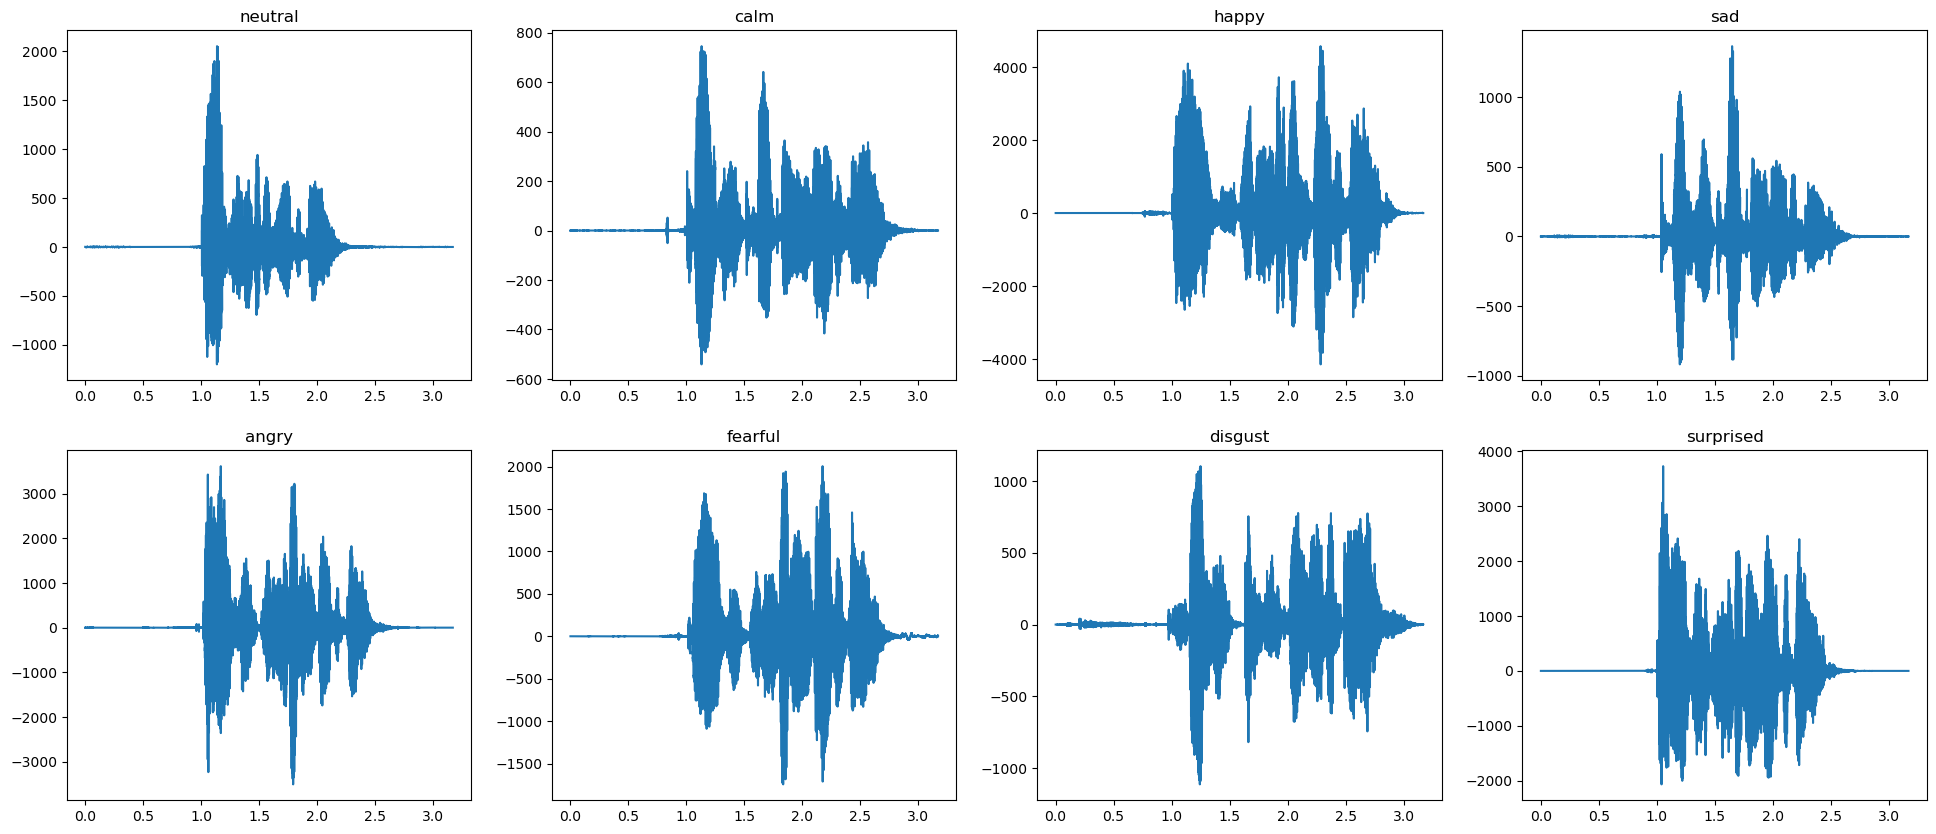

In [26]:
plt.figure(figsize=(24,10))
i=1
time=np.arange(0,length/fs,1/fs)
emotion_names=['neutral','calm','happy','sad','angry','fearful','disgust','surprised']
for sample in cropped_samples:
   plt.subplot(2,4,i)
   plt.plot(time,sample)
   plt.title(f'{emotion_names[i-1]}')
   i+=1

In [27]:
labels=[]
for file in all_files:
    if file[-18:-16]=='01':
        labels.append('neutral')
    elif file[-18:-16]=='02':
        labels.append('calm')
    elif file[-18:-16]=='03':
        labels.append('happy')
    elif file[-18:-16]=='04':
        labels.append('sad')
    elif file[-18:-16]=='05':
        labels.append('angry')
    elif file[-18:-16]=='06':
        labels.append('fearful')
    elif file[-18:-16]=='07':
        labels.append('disgust')
    elif file[-18:-16]=='08':
        labels.append('surprised')
print(len(labels))


1440


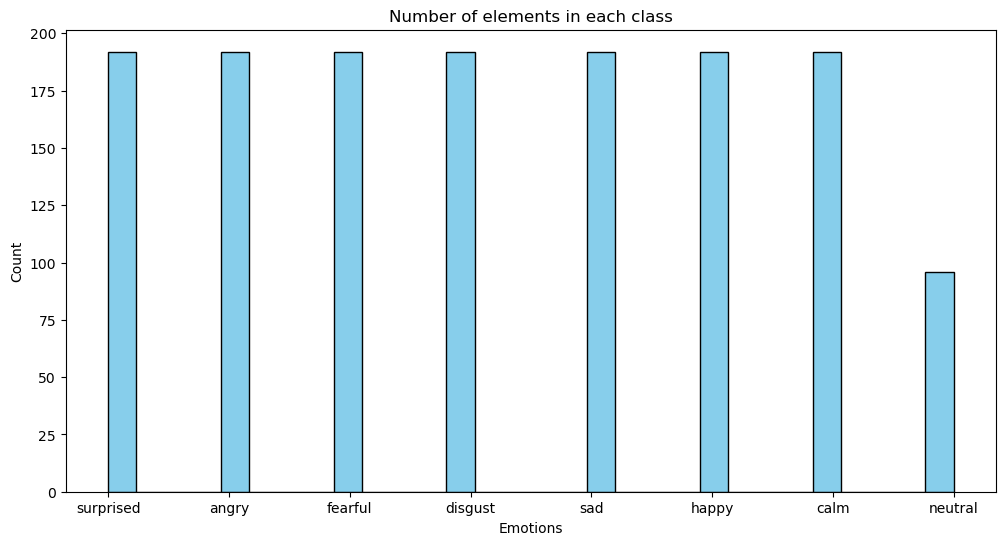

In [28]:
plt.figure(figsize=(12,6))
plt.hist(labels, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Emotions')
plt.ylabel('Count')
plt.title('Number of elements in each class')
plt.show()

PRZYKŁADOWE SPEKTROGRAMY DLA EMOCJI 

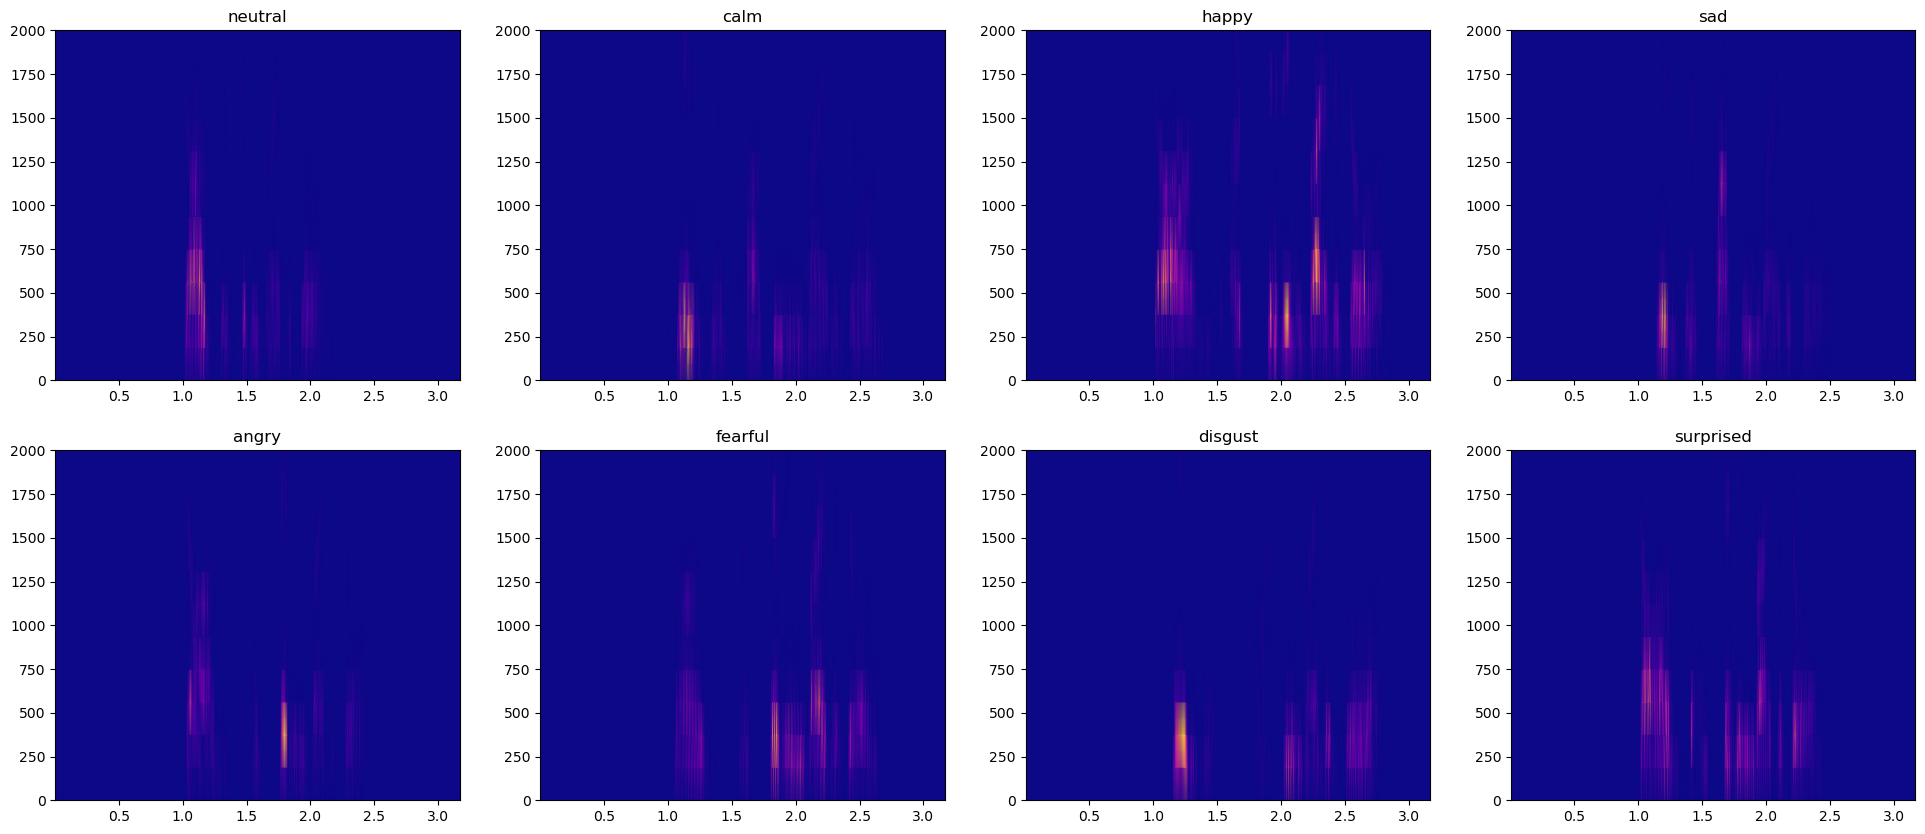

In [29]:
plt.figure(figsize=(24,10))
i=1
for sample in cropped_samples:
    plt.subplot(2,4,i)
    f, t, Sxx = spectrogram(sample, fs)
    plt.pcolormesh(t, f, Sxx, shading='gouraud', cmap='plasma')
    plt.ylim(0,2000)
    plt.title(f'{emotion_names[i-1]}')
    i+=1

PRZYGOTOWANIE MFCC razem z przycięciem do najkrótszego sygnału


In [30]:
mfccs = []
sig_len = []
for file in all_files:
    x, fs = librosa.load(file)
    mfcc_13_coeffs = librosa.feature.mfcc(y=x, sr=fs, n_mfcc=13)
    mfccs.append(mfcc_13_coeffs)
    sig_len.append(np.shape(mfcc_13_coeffs)[1])
prep_mfccs = []
for item in mfccs:
    item = item[:, :np.min(sig_len)]
    prep_mfccs.append(item)
mfccs = np.asarray(prep_mfccs)

[Text(0.5, 1.0, 'MFCC')]

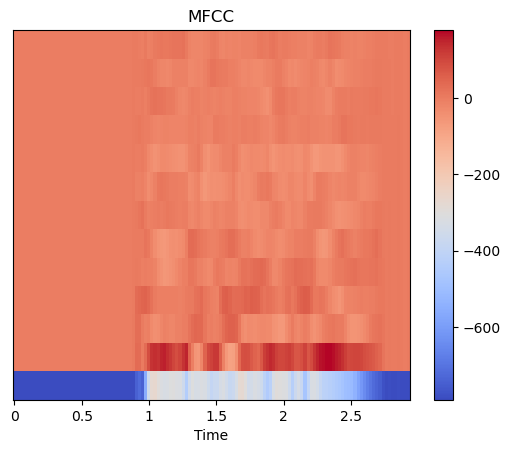

In [31]:
fig, ax = plt.subplots()
img = librosa.display.specshow(mfccs[0], x_axis='time', ax=ax)
fig.colorbar(img, ax=ax) 
ax.set(title='MFCC')

TESTOWY MODEL K Najbliżsych sąsiadów

In [32]:
X_train, X_test, y_train, y_test = train_test_split(mfccs, labels, test_size=0.2, random_state=42, stratify=labels)
X_train = np.array(X_train).reshape(np.shape(X_train)[0],-1)
X_test = X_test.reshape(np.shape(X_test)[0],-1)

In [33]:
clf = KNeighborsClassifier(n_neighbors=7) 
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

In [34]:
matrix=confusion_matrix(y_test, preds)

<Axes: title={'center': 'Confusion Matrix for KNN Classifier'}>

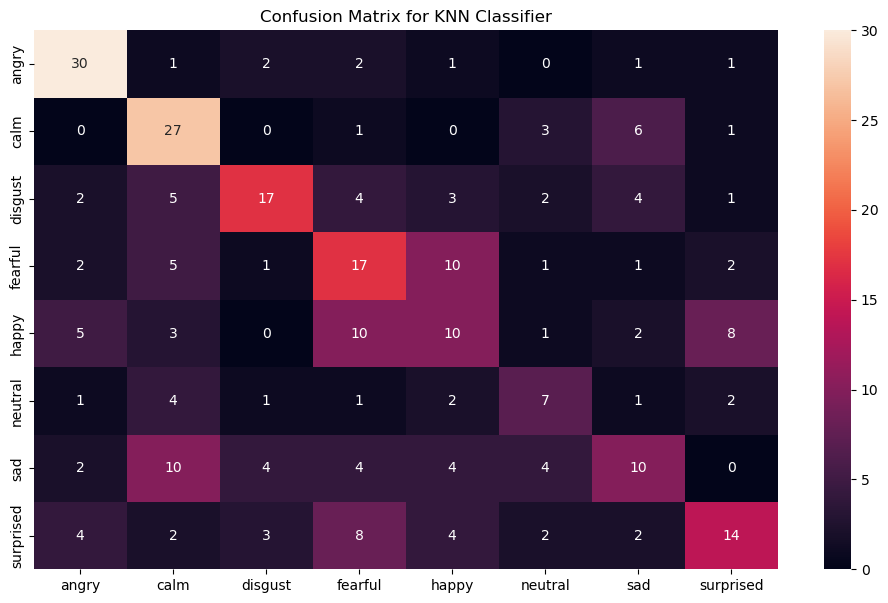

In [35]:

df_cm = pd.DataFrame(matrix, index = sorted(emotion_names),
                  columns = sorted(emotion_names))
plt.figure(figsize = (12,7))
plt.title('Confusion Matrix for KNN Classifier')
sn.heatmap(df_cm, annot=True)

In [36]:
f1=f1_score(y_pred=preds,y_true=y_test,average='weighted')
acc=accuracy_score(y_pred=preds,y_true=y_test)
print(f"Metrics for KNN model:\n"
      f"f1={f1}\n"
      f"accuracy={acc}")

Metrics for KNN model:
f1=0.44789512124603853
accuracy=0.4583333333333333
